In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import time
from tqdm import tqdm

import gdsfactory as gf
from DirectionalCoupler_GF import DirectionalCoupler

%matplotlib widget
import mplcursors
from mpl_interactions import zoom_factory
import addcopyfighandler

total_start = time.time()

# ----------------------------------------------------------------------------------
# Lumerical API path (uncomment for your machine) 
# ----------------------------------------------------------------------------------
sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python')  # QP5
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')           # QP3
# sys.path.append(r'C:\Program Files\Lumerical\v251\api\python')           # QP2

# ----------------------------------------------------------------------------------
# Paths
# ----------------------------------------------------------------------------------
WORKDIR   = Path().resolve()        # D:\...\scripts\directional_coupler
REPO_ROOT = WORKDIR.parents[1]     # D:\Ligentic_NU_1_TapeOut_April2026
os.chdir(WORKDIR)

data_save_dir = REPO_ROOT / "results_data" / "Data_directional_coupler"
data_save_dir.mkdir(parents=True, exist_ok=True)

print("Working dir :", WORKDIR)
print("Data save   :", data_save_dir)

Working dir : D:\Ligentic_NU_1_TapeOut_April2026\scripts\directional_coupler
Data save   : D:\Ligentic_NU_1_TapeOut_April2026\results_data\Data_directional_coupler


In [2]:
#------------------------------------------------------------
# LUMERICAL SESSION
#------------------------------------------------------------
sys.path.append(r'C:\Program Files\ANSYS Inc\v251\Lumerical\api\python')  
import lumapi as lm

try:
    f.redraw()
except NameError:
    print("Starting new Lumerical MODE session...")
    f = lm.MODE()
except AttributeError:
    print("Reinitializing Lumerical MODE session...")
    f = lm.MODE()

if f is None:
    raise RuntimeError("Failed to initialize Lumerical MODE session.")

LumFileName = "DirCoup_MultiSweep.lms"
LumFilePath = str(WORKDIR / LumFileName)
f.save(LumFilePath)

f.switchtolayout()
f.selectall()
f.delete()

Starting new Lumerical MODE session...


C:\Program Files\ANSYS Inc\v251\Lumerical\api\python\lumapi.py:895: SyntaxWarning: invalid escape sequence '\s'
  message = re.sub('^(Error:)\s(prompt line)\s[0-9]+:', '', str(rvals[2])).strip()


In [3]:
#------------------------------------------------------------
# PARAMETERS 
#------------------------------------------------------------
LambdaStart    = 1540E-9
LambdaStop     = 1560E-9

Height         = 800E-9
XLength        = 20E-6
YLength        = 10E-6

Material           = "Si3N4 (Silicon Nitride) - Luke"
use_index          = True
Index              = 1.97        # optional, used if material = '<Object defined dielectric>'
BackgroundMaterial = "SiO2 (Glass) - Palik"
SimulationTime     = 500E-12
FrequencyPoints    = 100

print(f"Frequency Points: {FrequencyPoints}")

#------------------------------------------------------------
# SWEEP LISTS  (Width, ArcRadius, CouplingLength, Gap)
#------------------------------------------------------------
Widths          = np.array([1200])* 1E-9
ArcRadii        = np.array([25])* 1E-6
CouplingLengths = np.array(np.arange(44,50,4))*1E-6
# CouplingLengths = np.array([12])*1E-6

Gaps            = np.array(np.arange(300,1010,50))*1E-9
Eulers           = [1]

Frequency Points: 100


  o1: center=(-92.00, -60.75) µm, orientation=180.0°
  o2: center=(92.00, -60.75) µm, orientation=0.0°
  o3: center=(-92.00, 60.75) µm, orientation=180.0°
  o4: center=(92.00, 60.75) µm, orientation=0.0°


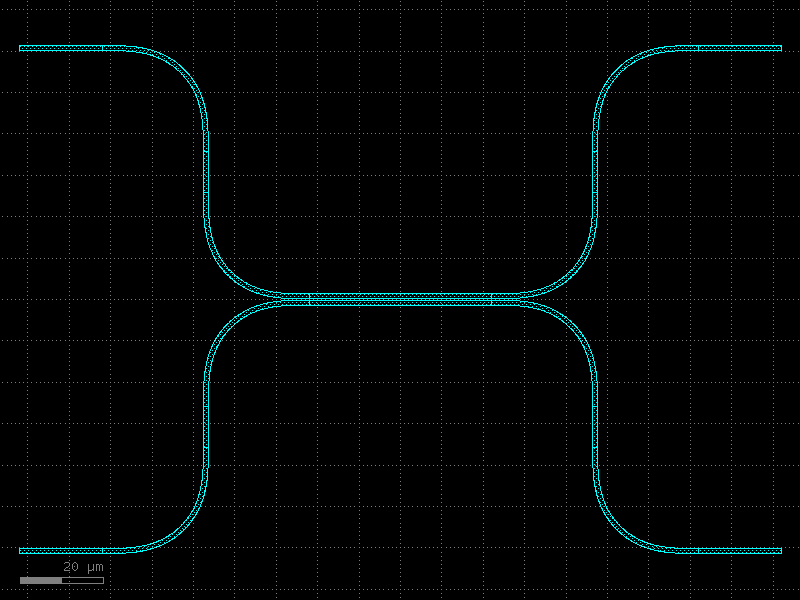

In [4]:
#------------------------------------------------------------
# GEOMETRY SETUP
#------------------------------------------------------------

gf.clear_cache()
dc = DirectionalCoupler(
    InLengthX=XLength * 1e6,
    LengthY=YLength * 1e6,
    CouplingLengthX=CouplingLengths[0] * 1e6,
    WgWidth=Widths[0] * 1e6,
    Radius=ArcRadii[0] * 1e6,
    Gap=Gaps[0] * 1e6,
    Layer=(2, 0),
)

gds_path = str(WORKDIR / "DC_test.gds")
dc.write_gds(gds_path)

# Verify ports
for p in dc.ports:
    print(f"  {p.name}: center=({p.dcenter[0]:.2f}, {p.dcenter[1]:.2f}) µm, orientation={p.orientation}°")

# Verify geometry
dc.plot()


In [5]:
#------------------------------------------------------------
# HELPER FUNCTIONS
#------------------------------------------------------------
def start_section(name):
    tqdm.write(f"🏃 {name}...")
    return time.time()

def end_section(start):
    tqdm.write(f"✅ {time.time() - start:.1f}s")

#------------------------------------------------------------
# MULTI-DIMENSIONAL SWEEP
#------------------------------------------------------------

if use_index:
    csv_path = data_save_dir / f"Kappa2_vs_gap_n{Index:.2f}_R{ArcRadii[0]*1e6:.0f}_W{Widths[0]*1e9:.0f}nm.csv"
else:
    csv_path = data_save_dir / f"Kappa2_vs_gap_LumIndex_R{ArcRadii[0]*1e6:.0f}_W{Widths[0]*1e9:.0f}nm.csv"
all_results = []

if csv_path.exists():
    all_results = pd.read_csv(csv_path).to_dict('records')
    print(f"Loaded {len(all_results)} existing rows from {csv_path}")
else:
    all_results = []
    print("No existing CSV found — starting fresh.")

for ArcRadius in tqdm(ArcRadii, desc="ArcRadius sweep", unit="R"):
    for Width in tqdm(Widths, desc="Width sweep", unit="W", leave=False):
        for Euler in tqdm(Eulers, desc="Euler sweep", leave=False):
            for CouplingLength in tqdm(CouplingLengths, desc="CL sweep", unit="CL", leave=False):
                for Gap in tqdm(Gaps, desc="Gap sweep", unit="gap", leave=False):

                    f.switchtolayout()
                    f.selectall()
                    f.delete()

                    tqdm.write(f"--- R={ArcRadius*1e6:.0f}µm | W={Width*1e9:.0f}nm | E={Euler} | CL={CouplingLength*1e6:.0f}µm | Gap={Gap*1e9:.0f}nm ---")
                    t = start_section("Geometry Setup")

                    #------------------------------------------------------------
                    # GDS GENERATION
                    #------------------------------------------------------------
                    gf.clear_cache()
                    dc = DirectionalCoupler(
                        InLengthX=XLength * 1e6,
                        LengthY=YLength * 1e6,
                        CouplingLengthX=CouplingLength * 1e6,
                        WgWidth=Width * 1e6,
                        Radius=ArcRadius * 1e6,
                        Gap=Gap * 1e6,
                        Euler=Euler,
                        Layer=(2, 0),
                    )
                    gds_path = str(WORKDIR / "DC_sweep.gds")
                    dc.write_gds(gds_path)
                    f.gdsimport(gds_path, dc.name, "2:0", Material, 0, Height)

                    if use_index:
                        f.set("material", "<Object defined dielectric>")
                        f.set("index", Index)

                    #------------------------------------------------------------
                    # BOUNDING BOX & PORTS
                    #------------------------------------------------------------
                    bbox   = dc.bbox()
                    margin = (LambdaStop + LambdaStart) / 2
                    x_span = (bbox.right - bbox.left) * 1e-6 - 8*margin
                    y_span = (bbox.top - bbox.bottom) * 1e-6 + 2 * margin

                    ports  = {p.name: (p.dcenter[0] * 1e-6, p.dcenter[1] * 1e-6) for p in dc.ports}
                    offset = 4e-6

                    SourcePosX =  -(x_span/2) + offset
                    TH_PosX    =   (x_span/2) - offset
                    CR_PosX    = TH_PosX

                    #------------------------------------------------------------
                    # varFDTD
                    #------------------------------------------------------------
                    f.addvarfdtd()
                    f.set("simulation time", SimulationTime)
                    f.set("x0", 0)
                    f.set("y0", Gap/2+Width/2)
                    f.set("x", 0)
                    f.set("x span", x_span)
                    f.set("y", 0)
                    f.set("y span", y_span)
                    f.set("z", Height / 2)
                    f.set("z span", 8 * Height)
                    f.set("background material", BackgroundMaterial)
                    f.set("set simulation bandwidth", 1)
                    f.set("bandwidth", "broadband")
                    f.set("simulation wavelength min", LambdaStart)
                    f.set("simulation wavelength max", LambdaStop)
                    f.set("auto shutoff min", 1E-5)

                    f.set("x min bc", "PML")
                    f.set("x max bc", "PML")
                    f.set("y min bc", "PML")
                    f.set("y max bc", "PML")
                    f.set("z min bc", "PML")
                    f.set("z max bc", "PML")

                    #------------------------------------------------------------
                    # SOURCE — at o3 (input), inject +x
                    #------------------------------------------------------------
                    f.addmodesource()
                    f.set("name", "ModeSource")
                    f.set("x", SourcePosX)
                    f.set("y", ports["o3"][1])
                    f.set("y span", 3 * Width)
                    f.set("injection axis", "x-axis")
                    f.set("direction", "Forward")
                    f.set("amplitude", 1.0)
                    f.set("phase", 0)
                    f.set("mode selection", "fundamental mode")
                    f.set("set wavelength", 1)
                    f.set("wavelength start", LambdaStart)
                    f.set("wavelength stop", LambdaStop)

                    #------------------------------------------------------------
                    # MONITOR: Through (at o4)
                    #------------------------------------------------------------
                    f.adddftmonitor()
                    f.set("name", "TH")
                    f.set("monitor type", "Linear Y")
                    f.set("x", TH_PosX)
                    f.set("y", ports["o4"][1])
                    f.set("y span", 3 * Width)
                    f.set("z", Height / 2)
                    f.set("override global monitor settings", 1)
                    f.set("use source limits", 1)
                    f.set("frequency points", FrequencyPoints)

                    #------------------------------------------------------------
                    # MONITOR: Cross (at o2)
                    #------------------------------------------------------------
                    f.adddftmonitor()
                    f.set("name", "CR")
                    f.set("monitor type", "Linear Y")
                    f.set("x", CR_PosX)
                    f.set("y", ports["o2"][1])
                    f.set("y span", 3 * Width)
                    f.set("z", Height / 2)
                    f.set("override global monitor settings", 1)
                    f.set("use source limits", 1)
                    f.set("frequency points", FrequencyPoints)

                    #------------------------------------------------------------
                    # MONITOR: Field
                    #------------------------------------------------------------
                    f.adddftmonitor()
                    f.set("name", "Field Monitor")
                    f.set("monitor type", "2D Z-normal")
                    f.set("x", 0)
                    f.set("x span", 2 * (ArcRadius / 2 + CouplingLength + LambdaStop))
                    f.set("y", 0)
                    f.set("y span", 10 * Width)
                    f.set("z", Height / 2)
                    f.set("override global monitor settings", 1)
                    f.set("use wavelength spacing", 1)
                    f.set("wavelength center", 1550E-9)
                    f.set("wavelength span", 1E-9)
                    f.set("frequency points", 1)

                    end_section(t)

                    #------------------------------------------------------------
                    # Run
                    #------------------------------------------------------------
                    t = start_section("Running solver")
                    f.run()
                    end_section(t)

                    #------------------------------------------------------------
                    # Extract Results
                    #------------------------------------------------------------
                    try:
                        T_TH = f.getresult("TH", "T")
                        T_CR = f.getresult("CR", "T")

                        Tx_Through = np.abs(T_TH["T"].flatten())
                        Tx_Cross   = np.abs(T_CR["T"].flatten())
                        Wavelength = T_TH["lambda"].flatten()
                    except Exception as e:
                        tqdm.write(f"  ⚠ SKIPPED | {e}")
                        continue

                    Tx_total_out = Tx_Through + Tx_Cross

                    idx_1550        = np.argmin(np.abs(Wavelength - 1550e-9))
                    kappa_sq_1550   = Tx_Cross[idx_1550] / (Tx_Cross[idx_1550] + Tx_Through[idx_1550])
                    loss_dB_1550    = -10 * np.log10(Tx_total_out[idx_1550])

                    tqdm.write(f"  κ²={kappa_sq_1550:.4f} | Loss={loss_dB_1550:.2f} dB")

                    #------------------------------------------------------------
                    # E-field plot (save only, no show)
                    #------------------------------------------------------------
                    E_field    = f.getresult("Field Monitor", "E")
                    idx_1550_E = np.argmin(np.abs(E_field['lambda'].flatten() - 1550e-9))

                    tag      = f"R{ArcRadius*1e6:.0f}um_W{Width*1e9:.0f}nm_E{Euler}_CL{CouplingLength*1e6:.0f}um_gap{Gap*1e9:.0f}nm"
                    fig_path = data_save_dir / f"Efield_DirCoup_{tag}.png"

                    try:
                        x = E_field['x'].flatten() * 1e6
                        y = E_field['y'].flatten() * 1e6
                        plt.figure(figsize=(6, 4))
                        plt.imshow(np.abs(E_field['E'][:, :, 0, idx_1550_E, 1]).T**2,
                                aspect='auto', cmap='hot', origin='lower',
                                extent=[x.min(), x.max(), y.min(), y.max()])
                        plt.xlabel('x (µm)')
                        plt.ylabel('y (µm)')
                        plt.colorbar(label='|Ey|²')
                        plt.title(f'Field Profile at 1550nm | {tag}')
                        plt.savefig(fig_path, dpi=150, bbox_inches='tight')
                        plt.close('all')
                    except Exception as e:
                        tqdm.write(f"  E-field save failed: {e}")
                        plt.close('all')

                    #------------------------------------------------------------
                    # Append to results (replace if exists)
                    #------------------------------------------------------------
                    new_row = {
                        "R"          : round(ArcRadius * 1e6, 3),
                        "W"          : round(Width * 1e9, 3),
                        "CL"         : round(CouplingLength * 1e6, 3),
                        "G"          : round(Gap * 1e9, 3),
                        "E"          : Euler,
                        "Kappa_sq"         : kappa_sq_1550,
                        "Loss"       : loss_dB_1550,
                        "Tx_Cross"   : Tx_Cross[idx_1550],
                        "Tx_Through" : Tx_Through[idx_1550],
                    }

                    key = ("R", "W", "E", "CL", "G")
                    match = next((i for i, r in enumerate(all_results)
                                if all(r[k] == new_row[k] for k in key)), None)
                    if match is not None:
                        all_results[match] = new_row
                        tqdm.write(f"  Updated existing row | κ²={kappa_sq_1550:.2%} | Loss={loss_dB_1550:.2f}dB")
                    else:
                        all_results.append(new_row)
                        tqdm.write(f"  New row added | κ²={kappa_sq_1550:.2%} | Loss={loss_dB_1550:.2f}dB")

                    pd.DataFrame(all_results).to_csv(csv_path, index=False)

#------------------------------------------------------------
# MASTER CSV
#------------------------------------------------------------
df = pd.DataFrame(all_results)
print(df)
print(f"\nMaster CSV saved to {csv_path}")

Loaded 620 existing rows from D:\Ligentic_NU_1_TapeOut_April2026\results_data\Data_directional_coupler\Kappa2_vs_gap_n1.97_R25_W1200nm.csv


ArcRadius sweep:   0%|          | 0/1 [00:00<?, ?R/s]





                                                     



                                      

                                            
                                              


ArcRadius sweep:   0%|          | 0/1 [00:00<?, ?R/s]





                                                     



                                      

                                            
                                              


ArcRadius sweep:   0%|          | 0/1 [00:00<?, ?R/s]







--- R=25µm | W=1200nm | E=1 | CL=44µm | Gap=300nm ---
🏃 Geometry Setup...


                                                     



                                      

                                            
                                              


ArcRadius sweep:   0%|          | 0/1 [00:01<?, ?R/s]





                                                     



                                      

                                            
                                              


ArcRadius sweep:   0%|          | 0/1 [00:01<?, ?R/s]







✅ 1.3s
🏃 Running solver...


...

--- R=25µm | W=1200nm | E=1 | CL=48µm | Gap=1000nm ---
🏃 Geometry Setup...


                                                     



                                                

                                            
                                              


ArcRadius sweep:   0%|          | 0/1 [59:48<?, ?R/s]    





                                                     



                                                

                                            
                                              


ArcRadius sweep:   0%|          | 0/1 [59:48<?, ?R/s]    







✅ 1.4s
🏃 Running solver...


                                                     



                                                

                                            
                                              


ArcRadius sweep:   0%|          | 0/1 [1:01:52<?, ?R/s]  





                                                       



                                                

                                              
                                                


ArcRadius sweep:   0%|          | 0/1 [1:01:52<?, ?R/s]    





                                                       



                                                

                                              
                                                


ArcRadius sweep:   0%|          | 0/1 [1:01:52<?, ?R/s]    

















ArcRadius sweep: 100%|██████████| 1/1 [1:01:52<00:00, 3712.28s/R]

✅ 123.1s
  κ²=0.0108 | Loss=0.00 dB
  New row added | κ²=1.08% | Loss=0.00dB
        R       W    CL       G  E  Kappa_sq      Loss  Tx_Cross  Tx_Through
0    25.0  1200.0   4.0   300.0  0  0.127756  0.072137  0.125652    0.857875
1    25.0  1200.0   4.0   350.0  0  0.095639  0.080549  0.093881    0.887742
2    25.0  1200.0   4.0   400.0  0  0.071762  0.080920  0.070437    0.911103
3    25.0  1200.0   4.0   450.0  0  0.055181  0.086861  0.054088    0.926110
4    25.0  1200.0   4.0   500.0  0  0.042963  0.093770  0.042046    0.936594
..    ...     ...   ...     ... ..       ...       ...       ...         ...
645  25.0  1200.0  48.0   800.0  1  0.055574  0.001923  0.055550    0.944008
646  25.0  1200.0  48.0   850.0  1  0.037273  0.001836  0.037258    0.962320
647  25.0  1200.0  48.0   900.0  1  0.024524  0.001758  0.024514    0.975081
648  25.0  1200.0  48.0   950.0  1  0.016419  0.001682  0.016412    0.983201
649  25.0  1200.0  48.0  1000.0  1  0.010808  0.001621  0.010804    0.988823

KeyError: 'Kx'

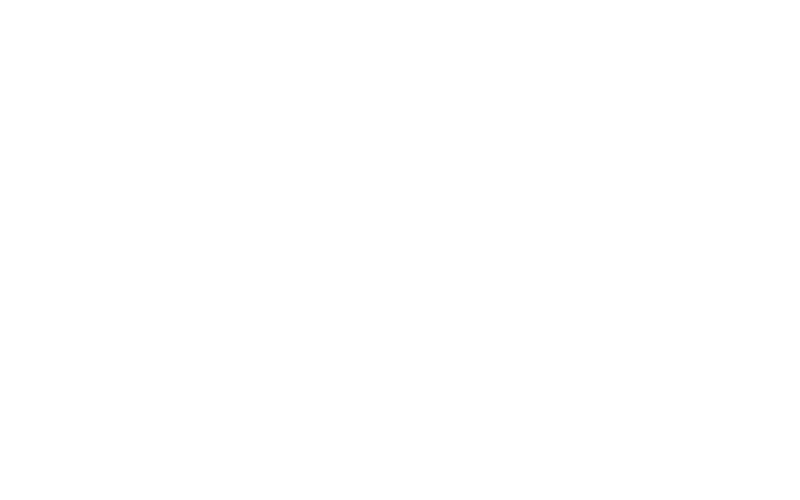

In [6]:
#------------------------------------------------------------
# LOAD & PLOT RESULTS
#------------------------------------------------------------


df = pd.read_csv(data_save_dir / "Kappa2_vs_gap_n1.97_R25_W1200nm.csv")

RW_pairs = df.groupby(["R", "W"]).groups.keys()

for (R, W) in RW_pairs:
    mask = (df["R"] == R) & (df["W"] == W)
    sub  = df[mask]

    plt.figure(figsize=(8, 5))
    for CL in sorted(sub["CL"].unique()):
        m = sub["CL"] == CL
        plt.plot(sub[m]["G"], sub[m]["Kx"], '-o', linewidth=1.5,
                label=f'Lc = {CL:.0f} µm')

    plt.xlabel('Gap (nm)')
    plt.ylabel('κ²')
    plt.title(f'Coupling Efficiency | R={R:.0f}µm  W={W:.0f}nm')
    plt.legend(loc='best')
    plt.grid()
    plt.tight_layout()
    plt.savefig(data_save_dir / f"Kx_vs_gap_R{R:.0f}um_W{W:.0f}nm.png", dpi=150, bbox_inches='tight')
    mplcursors.cursor(hover=True)
    disconnect_zoom = zoom_factory(plt.gca())
    plt.show()